# TNG50-4 Exploration

First look at the TNG50-4 simulation data (snapshot 099, z=0).
Uses `illustris_python` to load group catalogs and particle data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import h5py
from galaxy_sidm.observables import compute_circularity, disc_fraction, velocity_dispersion_1d, v_over_sigma, lambda_R

basePath = "../../data/TNG50-4/output"
snap = 99
with h5py.File(f"{basePath}/snapdir_099/snap_099.0.hdf5", "r") as f: header = dict(f["Header"].attrs)
h = header["HubbleParam"]
box_ckpc_h = header["BoxSize"]

⏱ 1.3697s


In [2]:
print(f"h = {h}")
print(f"BoxSize = {box_ckpc_h:.0f} ckpc/h = {box_ckpc_h / h:.0f} ckpc = {box_ckpc_h / h / 1e3:.1f} cMpc")

h = 0.6774
BoxSize = 35000 ckpc/h = 51668 ckpc = 51.7 cMpc
⏱ 0.0005s


In [3]:
# Load group (halo) catalog
halos = il.groupcat.loadHalos(
    basePath, snap,
    fields=[
        "GroupMass", "Group_M_Crit200", "GroupNsubs", "GroupFirstSub",
        "GroupPos", "Group_R_Crit200",
    ],
)

# Load subhalo catalog
subs = il.groupcat.loadSubhalos(
    basePath, snap,
    fields=[
        "SubhaloMassType", "SubhaloSFR", "SubhaloFlag",
        "SubhaloPos", "SubhaloVmax", "SubhaloHalfmassRadType",
        "SubhaloLenType", "SubhaloSpin", "SubhaloVmaxRad",
    ],
)

n_halos = halos["count"]
n_subs = subs["count"]

print(f"TNG50-4, snapshot {snap} (z=0)")
print(f"  FoF halos:  {n_halos}")
print(f"  Subhalos:   {n_subs}")

TNG50-4, snapshot 99 (z=0)
  FoF halos:  25257
  Subhalos:   22869
⏱ 0.0447s


In [4]:
# Convert stellar mass from code units to solar masses
stellar_mass_msun = subs["SubhaloMassType"][:, 4] * 1e10 / h  # Msun

# Only keep "cosmological" subhalos (SubhaloFlag == True)
flag = subs["SubhaloFlag"]

# Top 10 most massive (by stellar mass)
top10_idx = np.argsort(stellar_mass_msun[flag])[-10:][::-1]
# Map back to original indices (since we filtered by flag)
flagged_indices = np.where(flag)[0]
top10 = flagged_indices[top10_idx]

print(f"{'Rank':<5} {'SubhaloID':<12} {'M*(Msun)':>14} {'SFR(Msun/yr)':>14} {'N_star':>8} {'Vmax(km/s)':>12} {'Rmax(kpc)':>12}")
print("-" * 83)
for i, idx in enumerate(top10):
    print(
        f"{i+1:<5} {idx:<12} {stellar_mass_msun[idx]:>14.3e} "
        f"{subs['SubhaloSFR'][idx]:>14.3f} "
        f"{subs['SubhaloLenType'][idx, 4]:>8} "
        f"{subs['SubhaloVmax'][idx]:>12.1f} "
        f"{subs['SubhaloVmaxRad'][idx]:>12.1f}"
    )

Rank  SubhaloID          M*(Msun)   SFR(Msun/yr)   N_star   Vmax(km/s)    Rmax(kpc)
-----------------------------------------------------------------------------------
1     0                 1.353e+12          0.000    43861        878.6        305.3
2     503               5.051e+11          0.483    16380        589.3        234.4
3     308               3.990e+11          0.000    12812        644.0        378.4
4     1103              3.858e+11          0.000    12629        499.5        157.0
5     636               3.722e+11          0.000    12161        439.6        282.4
6     1523              2.558e+11          0.000     8227        355.8        149.7
7     1018              2.540e+11          0.000     8240        462.6        249.1
8     1149              2.508e+11          0.000     8212        456.1        177.5
9     1642              2.177e+11          0.072     7145        317.5        144.2
10    1329              2.050e+11          0.000     6515        439.2      

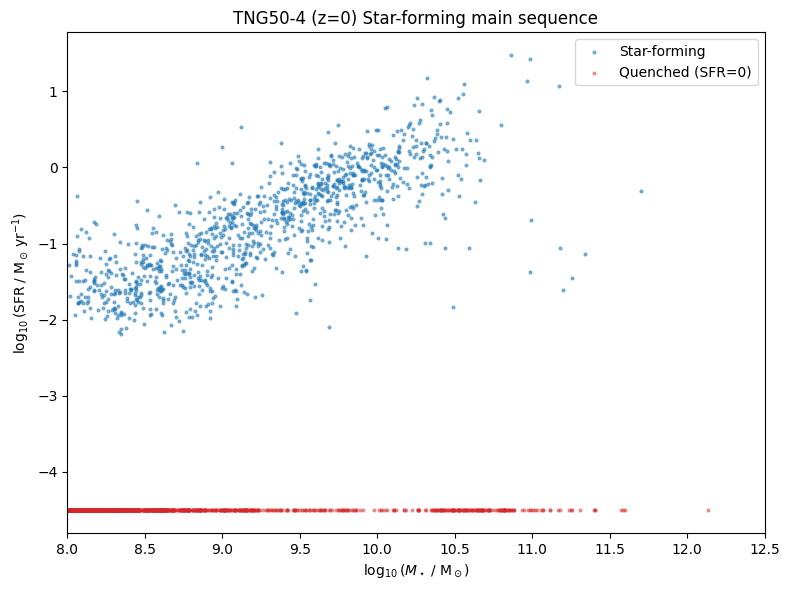

⏱ 0.1762s


In [5]:
# Filter: flagged subhalos with M* > 1e8 Msun (resolved galaxies)
mask = flag & (stellar_mass_msun > 1e8)

mstar = stellar_mass_msun[mask]
sfr = subs["SubhaloSFR"][mask]  # already in Msun/yr

# Split into star-forming and quenched for coloring
sf_mask = sfr > 0
quenched_mask = ~sf_mask

fig, ax = plt.subplots(figsize=(8, 6))

# Star-forming galaxies
ax.scatter(
    np.log10(mstar[sf_mask]), np.log10(sfr[sf_mask]),
    s=4, alpha=0.5, c="tab:blue", label="Star-forming",
)

# Quenched galaxies (SFR = 0) — plot at bottom
if quenched_mask.sum() > 0:
    ax.scatter(
        np.log10(mstar[quenched_mask]),
        np.full(quenched_mask.sum(), -4.5),
        s=4, alpha=0.4, c="tab:red", label="Quenched (SFR=0)",
    )

ax.set_xlabel(r"$\log_{10}(M_\star\;/\;\mathrm{M_\odot})$")
ax.set_ylabel(r"$\log_{10}(\mathrm{SFR}\;/\;\mathrm{M_\odot\,yr^{-1}})$")
ax.set_title("TNG50-4 (z=0) Star-forming main sequence")
ax.legend()
ax.set_xlim(8, 12.5)
# ax.set_ylim(-5, 2.5)
plt.tight_layout()
plt.savefig("figures/mstar_sfr_tng50-4.png", dpi=150)
plt.show()

In [6]:
# Pick the most massive subhalo
sub_id = top10[0]
print(f"Loading star particles for subhalo {sub_id} "
      f"(M* = {stellar_mass_msun[sub_id]:.2e} Msun)")

stars = il.snapshot.loadSubhalo(
    basePath, snap, sub_id, "stars",
    fields=["Coordinates", "Velocities", "Masses", "GFM_StellarFormationTime"],
)

print(f"  {stars['count']} star particles loaded")

Loading star particles for subhalo 0 (M* = 1.35e+12 Msun)
  43861 star particles loaded
⏱ 0.0069s


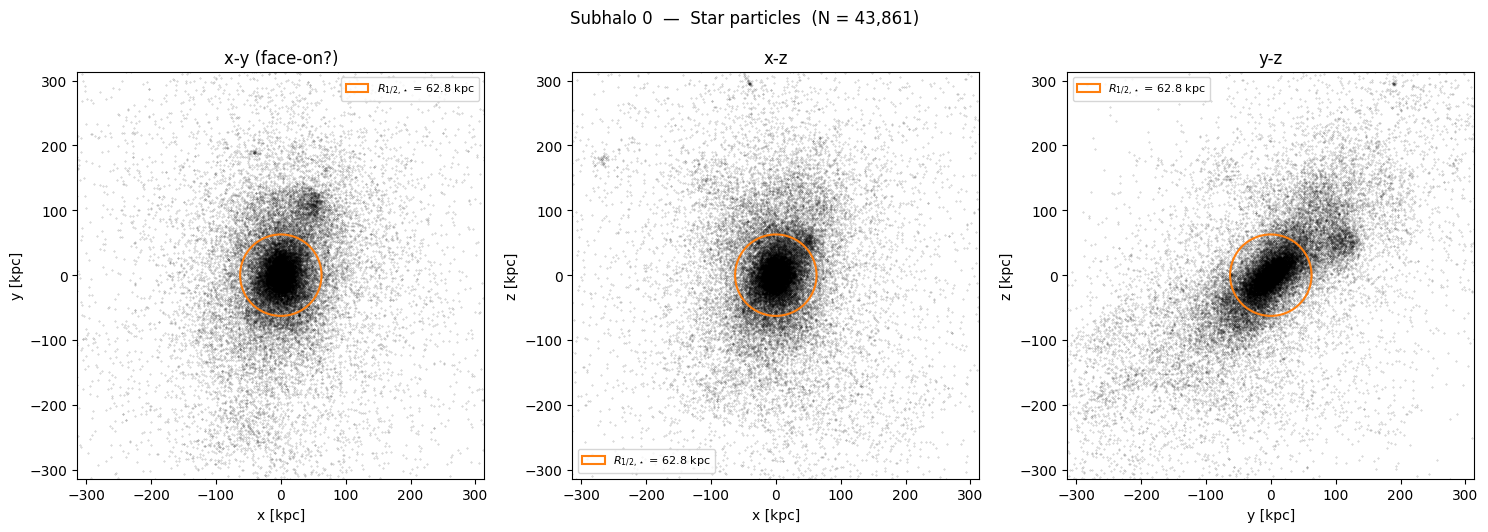

⏱ 1.7424s


In [7]:
# Centre on the subhalo position and convert to physical kpc
pos = stars["Coordinates"] / h  # ckpc/h -> ckpc (at z=0, ckpc = pkpc)
centre = subs["SubhaloPos"][sub_id] / h
pos -= centre  # relative to subhalo centre

# Stellar half-mass radius for scale reference
r_half_star = subs["SubhaloHalfmassRadType"][sub_id, 4] / h  # kpc

# 2D projections
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

projections = [("x-y (face-on?)", 0, 1), ("x-z", 0, 2), ("y-z", 1, 2)]
labels = ["xyz"[i] for i in range(3)]
lim = 5 * r_half_star  # zoom to 5x half-mass radius

for ax, (title, i, j), in zip(axes, projections):
    ax.scatter(pos[:, i], pos[:, j], s=0.1, alpha=0.3, c="k", rasterized=True)
    circle = plt.Circle((0, 0), r_half_star, fill=False, color="tab:orange",
                         linewidth=1.5, label=f"$R_{{1/2,\\star}}$ = {r_half_star:.1f} kpc")
    ax.add_patch(circle)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"{'xyz'[i]} [kpc]")
    ax.set_ylabel(f"{'xyz'[j]} [kpc]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

fig.suptitle(f"Subhalo {sub_id}  —  Star particles  (N = {stars['count']:,})", y=1.02)
plt.tight_layout()
plt.savefig("figures/star_particles_tng50-4.png", dpi=150, bbox_inches="tight")
plt.show()

The circularity parameter measures how circular a star's orbit is:
- $\epsilon = +1$: perfectly co-rotating circular orbit (disc)
- $\epsilon = -1$: counter-rotating circular orbit
- $\epsilon \approx 0$: radial orbit (bulge/halo)

Steps:
1. Compute each star's specific angular momentum $\vec{j} = \vec{r} \times \vec{v}$
2. Define the z-axis from the total angular momentum of young stars (or all stars within $R_{1/2}$)
3. $j_z$ = component along that axis
4. $j_{\rm circ}(E)$ = angular momentum of a circular orbit with the same energy, estimated from the maximum $|j_z|$ in energy bins

In [8]:
# Also load gravitational potential for energy calculation
stars_full = il.snapshot.loadSubhalo(
    basePath, snap, sub_id, "stars",
    fields=["Coordinates", "Velocities", "Masses", "Potential",
            "GFM_StellarFormationTime"],
)

# Convert units
pos = stars_full["Coordinates"] / h - centre      # kpc, centred
vel = stars_full["Velocities"]                      # km/s at z=0
mass = stars_full["Masses"] * 1e10 / h              # Msun
pot = stars_full["Potential"]                        # (km/s)^2 / a (at z=0, just (km/s)^2)
a_form = stars_full["GFM_StellarFormationTime"]      # scale factor of formation

# Centre velocities on mass-weighted mean (bulk velocity)
vel -= np.average(vel, axis=0, weights=mass)

# Radial distance
r = np.linalg.norm(pos, axis=1)

print(f"Loaded {len(r):,} star particles")
print(f"Median radius: {np.median(r):.1f} kpc")

Loaded 43,861 star particles
Median radius: 59.4 kpc
⏱ 0.0070s


In [9]:
epsilon = compute_circularity(pos, vel, mass, pot, r_half_star)

print(f"Circularity computed for {len(epsilon):,} particles")
print(f"  median eps = {np.nanmedian(epsilon):.3f}")
print(f"  fraction with eps > 0.7 (disc): {np.nanmean(epsilon > 0.7):.1%}")
print(f"  fraction with |eps| < 0.3 (bulge-like): {np.nanmean(np.abs(epsilon) < 0.3):.1%}")
print(f"  D/T = {disc_fraction(epsilon, mass):.3f}")

Circularity computed for 43,861 particles
  median eps = 0.023
  fraction with eps > 0.7 (disc): 2.4%
  fraction with |eps| < 0.3 (bulge-like): 62.2%
  D/T = 0.024
⏱ 0.0062s


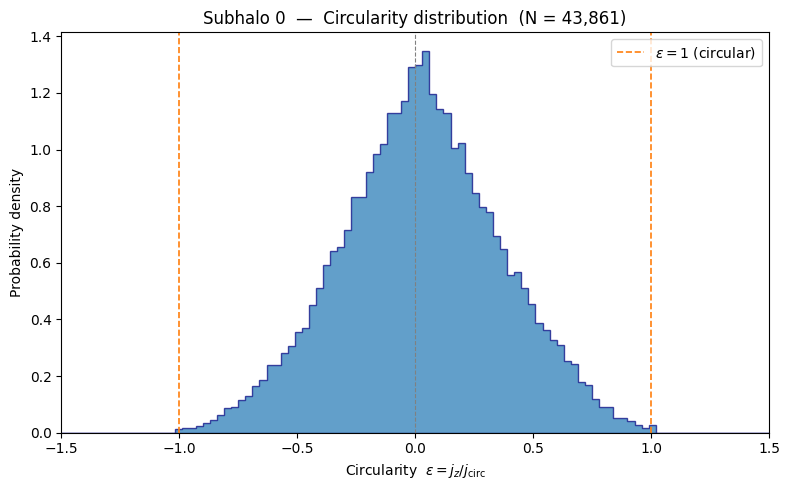

⏱ 0.0850s


In [10]:
# Plot circularity distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(epsilon, bins=100, range=(-1.5, 1.5), density=True,
        histtype="stepfilled", alpha=0.7, color="tab:blue", edgecolor="navy")

ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.axvline(1, color="tab:orange", ls="--", lw=1.2, label=r"$\epsilon = 1$ (circular)")
ax.axvline(-1, color="tab:orange", ls="--", lw=1.2)

ax.set_xlabel(r"Circularity  $\epsilon = j_z / j_{\rm circ}$")
ax.set_ylabel("Probability density")
ax.set_title(f"Subhalo {sub_id}  —  Circularity distribution  (N = {len(epsilon):,})")
ax.legend()
ax.set_xlim(-1.5, 1.5)
plt.tight_layout()
plt.savefig("figures/circularity_tng50-4.png", dpi=150)
plt.show()

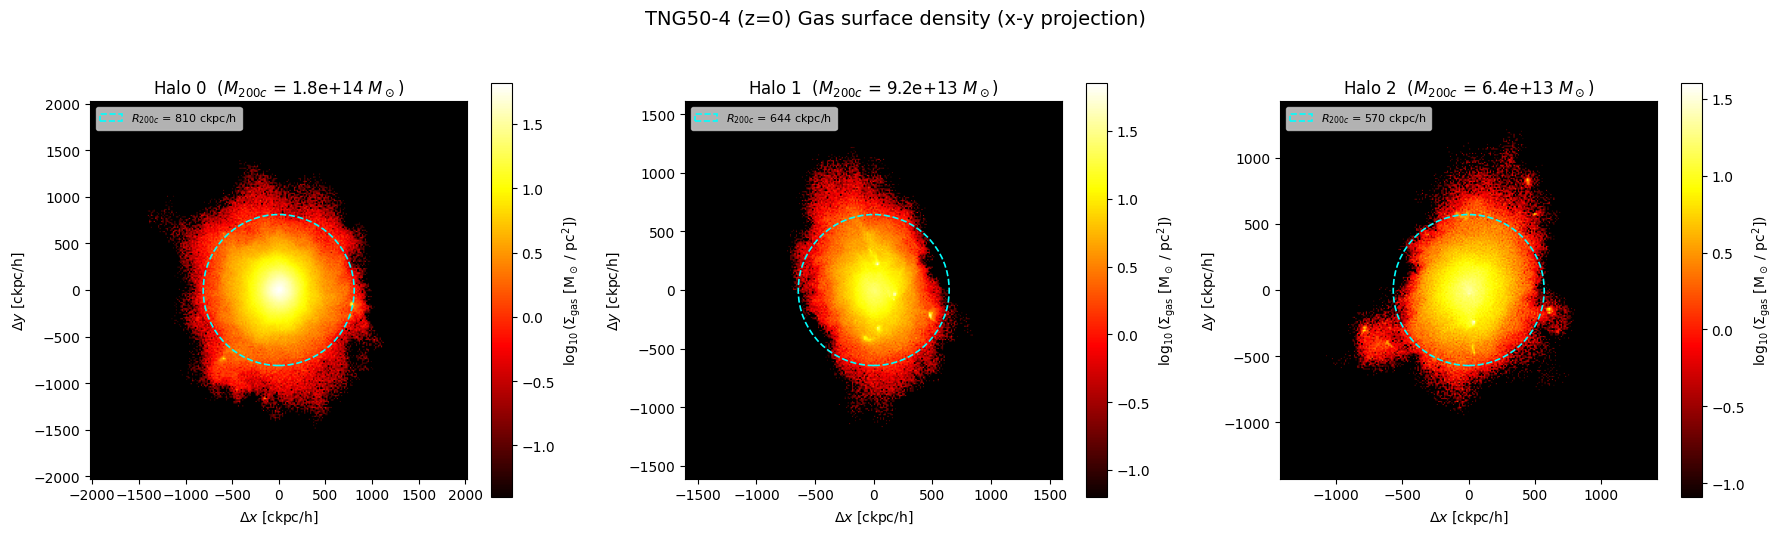

⏱ 0.4900s


In [11]:
# Identify the 3 most massive FoF halos by M200c
halo_m200c = halos["Group_M_Crit200"] * 1e10 / h  # Msun
top3_halos = np.argsort(halo_m200c)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, halo_id in zip(axes, top3_halos):
    # Load gas particles for this FoF halo
    gas = il.snapshot.loadHalo(
        basePath, snap, halo_id, "gas",
        fields=["Coordinates", "Masses"],
    )

    # Keep positions in code units (ckpc/h) to match TNG convention
    gas_pos = gas["Coordinates"] - halos["GroupPos"][halo_id]
    gas_mass = gas["Masses"]  # code units, used as weight

    r200_code = halos["Group_R_Crit200"][halo_id]  # ckpc/h

    # Mass-weighted 2D histogram (x-y projection)
    lim = 2.5 * r200_code
    nbins = 256
    bin_width = 2 * lim / nbins  # ckpc/h per bin
    H, xedges, yedges = np.histogram2d(
        gas_pos[:, 0], gas_pos[:, 1],
        bins=nbins, range=[[-lim, lim], [-lim, lim]],
        weights=gas_mass,
    )

    # Convert to surface density: M_sun / pc^2
    # mass is in 1e10 Msun/h, bin area in (ckpc/h)^2
    # Sigma = (H * 1e10 / h) / (bin_width / h)^2 = H * 1e10 * h / bin_width^2
    sigma = H * 1e10 * h / bin_width**2 / 1e6  # Msun / pc^2

    sigma[sigma == 0] = np.nan
    im = ax.imshow(
        np.log10(sigma.T), origin="lower", extent=[-lim, lim, -lim, lim],
        cmap="hot", aspect="equal",
    )

    # R200 circle
    circle = plt.Circle(
        (0, 0), r200_code, fill=False, color="cyan", ls="--", lw=1.2,
        label=f"$R_{{200c}}$ = {r200_code:.0f} ckpc/h",
    )
    ax.add_patch(circle)

    ax.set_xlabel(r"$\Delta x$ [ckpc/h]")
    ax.set_ylabel(r"$\Delta y$ [ckpc/h]")
    ax.set_title(
        f"Halo {halo_id}  ($M_{{200c}}$ = {halo_m200c[halo_id]:.1e} $M_\\odot$)"
    )
    ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
    ax.set_facecolor("black")
    plt.colorbar(im, ax=ax, label=r"$\log_{10}(\Sigma_{\rm gas}$ [M$_\odot$ / pc$^2$])", shrink=0.85)

fig.suptitle("TNG50-4 (z=0) Gas surface density (x-y projection)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/gas_density_top3_halos_tng50-4.png", dpi=150, bbox_inches="tight")
plt.show()

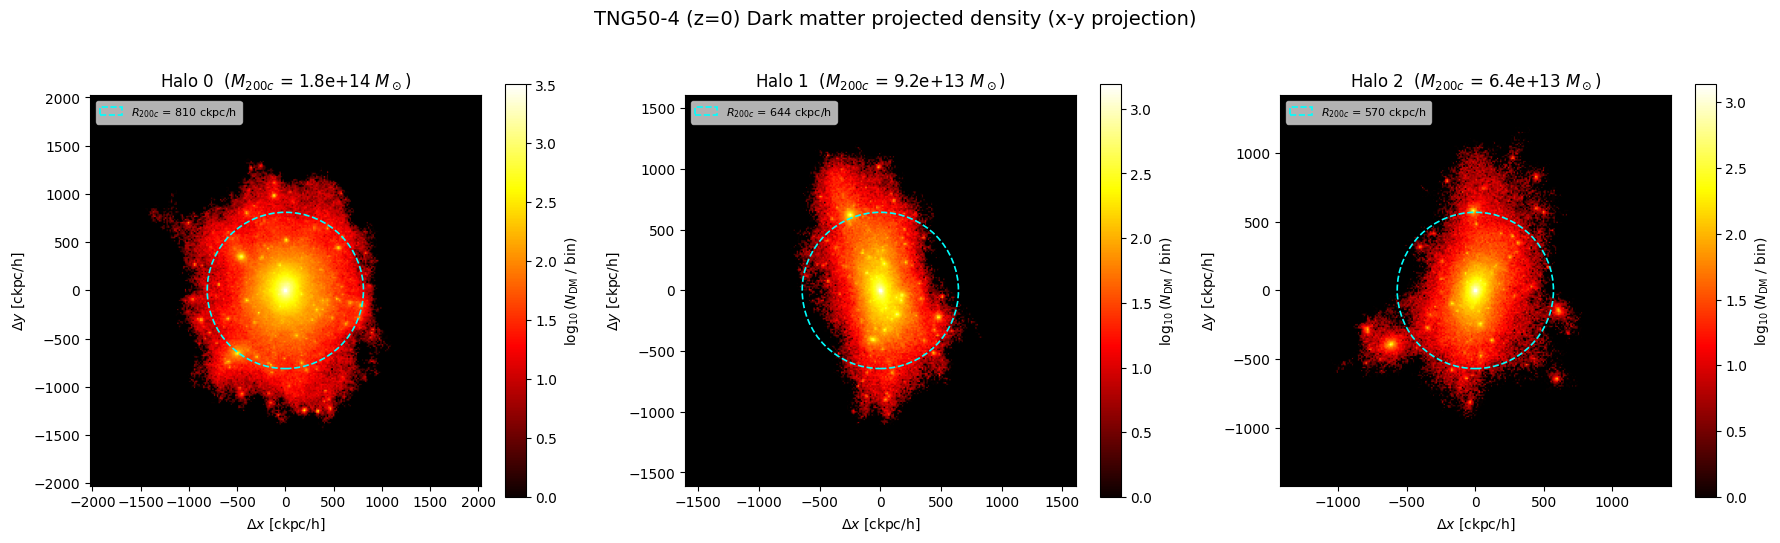

⏱ 0.5451s


In [12]:
# Same plot for dark matter particles
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, halo_id in zip(axes, top3_halos):
    # Request 2 fields so illustris_python returns a dict (single field returns raw array)
    dm = il.snapshot.loadHalo(
        basePath, snap, halo_id, "dm",
        fields=["Coordinates", "ParticleIDs"],
    )

    dm_pos = dm["Coordinates"] - halos["GroupPos"][halo_id]
    r200_code = halos["Group_R_Crit200"][halo_id]

    # DM particles all have the same mass, so unweighted histogram is fine
    lim = 2.5 * r200_code
    nbins = 256
    H, xedges, yedges = np.histogram2d(
        dm_pos[:, 0], dm_pos[:, 1],
        bins=nbins, range=[[-lim, lim], [-lim, lim]],
    )

    H[H == 0] = np.nan
    im = ax.imshow(
        np.log10(H.T), origin="lower", extent=[-lim, lim, -lim, lim],
        cmap="hot", aspect="equal",
    )

    circle = plt.Circle(
        (0, 0), r200_code, fill=False, color="cyan", ls="--", lw=1.2,
        label=f"$R_{{200c}}$ = {r200_code:.0f} ckpc/h",
    )
    ax.add_patch(circle)

    ax.set_xlabel(r"$\Delta x$ [ckpc/h]")
    ax.set_ylabel(r"$\Delta y$ [ckpc/h]")
    ax.set_title(
        f"Halo {halo_id}  ($M_{{200c}}$ = {halo_m200c[halo_id]:.1e} $M_\\odot$)"
    )
    ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
    ax.set_facecolor("black")
    plt.colorbar(im, ax=ax, label=r"$\log_{10}(N_{\rm DM}$ / bin)", shrink=0.85)

fig.suptitle("TNG50-4 (z=0) Dark matter projected density (x-y projection)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/dm_density_top3_halos_tng50-4.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
%%time
# Select resolved galaxies: M* > 1e10 Msun, flagged
mass_cut = 1e10
resolved_mask = flag & (stellar_mass_msun > mass_cut)
resolved_ids = np.where(resolved_mask)[0]

print(f"Computing D/T for {len(resolved_ids)} galaxies with M* > {mass_cut:.0e} Msun ...")

dt_ratios = np.full(len(resolved_ids), np.nan)
for i, sid in enumerate(resolved_ids):
    sub_pos = subs["SubhaloPos"][sid]
    r_half_code = subs["SubhaloHalfmassRadType"][sid, 4] # stars

    stars_i = il.snapshot.loadSubhalo(
        basePath, snap, sid, "stars",
        fields=["Coordinates", "Velocities", "Masses", "Potential"],
    )
    if stars_i["count"] < 100:
        continue

    pos_i = stars_i["Coordinates"] / h - sub_pos / h
    vel_i = stars_i["Velocities"].copy()
    mass_i = stars_i["Masses"] * 1e10 / h
    pot_i = stars_i["Potential"]

    vel_i -= np.average(vel_i, axis=0, weights=mass_i)

    eps_i = compute_circularity(pos_i, vel_i, mass_i, pot_i, r_half_code / h)
    dt_ratios[i] = disc_fraction(eps_i, mass_i)

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(resolved_ids)} done ...")

valid = ~np.isnan(dt_ratios)
print(f"\nDone. {valid.sum()}/{len(resolved_ids)} successful.")
print(f"Median D/T = {np.nanmedian(dt_ratios):.3f}")
print(f"Disc-dominated (D/T > 0.5): {np.sum(dt_ratios[valid] > 0.5)} / {valid.sum()}")

Computing D/T for 338 galaxies with M* > 1e+10 Msun ...
  50/338 done ...
  100/338 done ...
  150/338 done ...
  200/338 done ...
  250/338 done ...
  300/338 done ...

Done. 338/338 successful.
Median D/T = 0.162
Disc-dominated (D/T > 0.5): 1 / 338
CPU times: user 424 ms, sys: 81 ms, total: 505 ms
Wall time: 594 ms
⏱ 0.5950s


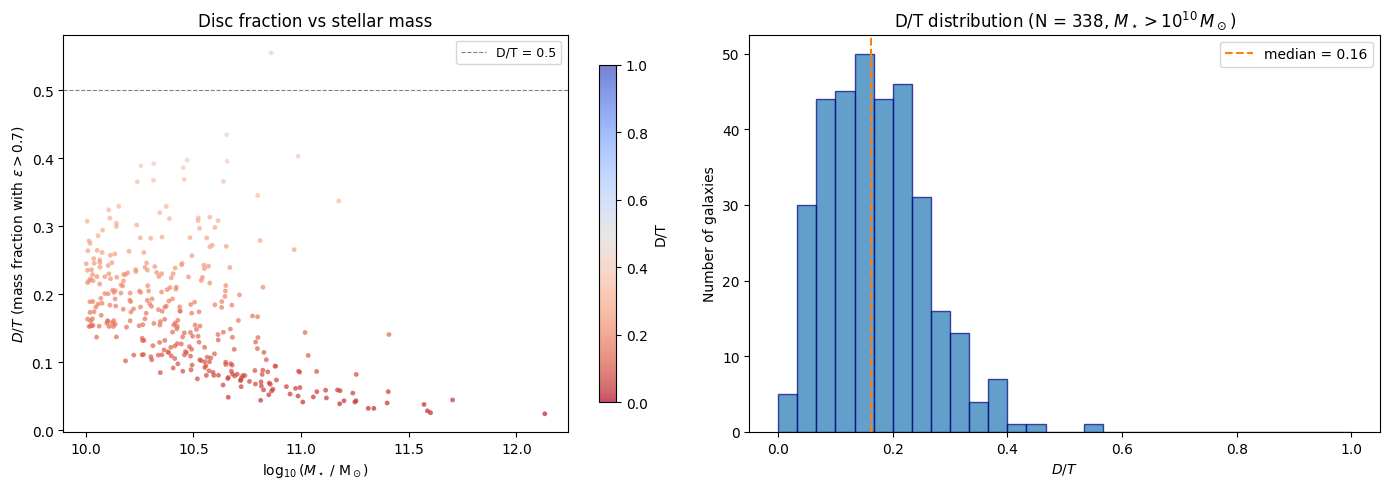

⏱ 0.1939s


In [14]:
resolved_mstar = stellar_mass_msun[resolved_ids][valid]
dt_valid = dt_ratios[valid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: D/T vs stellar mass
ax = axes[0]
sc = ax.scatter(
    np.log10(resolved_mstar), dt_valid,
    c=dt_valid, cmap="coolwarm_r", s=12, alpha=0.7,
    vmin=0, vmax=1, edgecolors="none",
)
ax.set_xlabel(r"$\log_{10}(M_\star\;/\;\mathrm{M_\odot})$")
ax.set_ylabel(r"$D/T$ (mass fraction with $\epsilon > 0.7$)")
ax.set_title("Disc fraction vs stellar mass")
ax.axhline(0.5, color="gray", ls="--", lw=0.8, label="D/T = 0.5")
# ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label="D/T", shrink=0.85)

# Right: D/T histogram
ax = axes[1]
ax.hist(dt_valid, bins=30, range=(0, 1), edgecolor="navy",
        color="tab:blue", alpha=0.7)
ax.set_xlabel(r"$D/T$")
ax.set_ylabel("Number of galaxies")
ax.set_title(f"D/T distribution (N = {len(dt_valid)}, $M_\\star > 10^{{10}}\\,M_\\odot$)")
ax.axvline(np.median(dt_valid), color="tab:orange", ls="--", lw=1.5,
           label=f"median = {np.median(dt_valid):.2f}")
ax.legend()

plt.tight_layout()
plt.savefig("figures/disc_fraction_population_tng50-4.png", dpi=150)
plt.show()